# T1 · Camera degradation health score — Nhóm GTAA

**Nền tảng:** xe ADAS · **Sensor:** camera trước · **Tính năng:** phát hiện vật thể (YOLOv8n, weights COCO)

**Claim:** khi camera bị nhòe, nhiễu hoặc thiếu sáng mạnh hơn, chỉ số sức khỏe ảnh thay đổi và mAP@0.5 giảm.
Câu hỏi kèm theo: chỉ số sức khỏe nào *báo trước* được mAP giảm, và độ tự tin của detector có tự nhận ra ảnh hỏng không?

Notebook này chỉ gọi code trong `src/` và hiển thị kết quả; logic nằm ở `src/benchmark.py`
(chạy lại bằng dòng lệnh: `python src/benchmark.py --n 200`). Thiết kế, định nghĩa metric và nguồn: xem `README.md`.

In [1]:
import sys, json, platform
from pathlib import Path
sys.path.insert(0, "src")
import pandas as pd
from IPython.display import Image, display
import benchmark as bm

pd.set_option("display.precision", 3)
print("Python", platform.python_version(), "| ultralytics", bm.ultralytics.__version__,
      "| opencv", bm.cv2.__version__, "| numpy", bm.np.__version__)
print("BDD100K_ROOT =", bm.BDD100K_ROOT.relative_to(bm.ROOT) if bm.BDD100K_ROOT.is_relative_to(bm.ROOT) else bm.BDD100K_ROOT)

Python 3.10.19 | ultralytics 8.4.171 | opencv 4.10.0 | numpy 1.26.4
BDD100K_ROOT = data/bdd100k


## 1. Dữ liệu

BDD100K (tập val, 10.000 ảnh, bản FiftyOne `dgural/bdd100k`). Baseline: 200 ảnh **ban ngày, trời quang**, bốc
ngẫu nhiên với seed 0. Lát cắt đối chiếu: 200 ảnh **ban đêm, trời quang** (lỗi thật, nhưng là ảnh khác).

In [2]:
samples = json.load(open(bm.BDD100K_ROOT / "samples.json"))["samples"]
attrs = pd.DataFrame({"timeofday": [s["timeofday"]["label"] for s in samples],
                      "weather": [s["weather"]["label"] for s in samples]})
print(len(samples), "ảnh trong BDD100K val")
pd.crosstab(attrs.timeofday, attrs.weather)

10000 ảnh trong BDD100K val


weather,clear,foggy,overcast,partly cloudy,rainy,snowy,undefined
timeofday,,,,,,,
dawn/dusk,307,1,182,95,55,74,64
daytime,1764,5,1039,638,396,422,994
night,3274,7,18,5,286,273,66
undefined,1,0,0,0,1,0,33


## 2. Phương pháp tạo lỗi lấy từ nguồn S5

Dong et al., CVPR 2023 — repo `thu-ml/3D_Corruptions_AD` @ `48c23f7`, file `Camera_corruptions.py`.
Hai họ lỗi dùng **đúng định nghĩa severity 1/3/5** của S5: zoom blur trước-sau (`ImageMotionBlurFrontBack`, lỗi
motion blur camera mặc định của họ trên KITTI) và nhiễu Gauss (`ImageAddGaussianNoise` → ImageNet-C).
File gốc phụ thuộc imgaug + mmdet3d nên nhóm viết lại bằng OpenCV; ô dưới so bản viết lại với logic gốc của S5.

In [3]:
import check_s5_port
check_s5_port.main()

b1c66a42-6f7d68ca.jpg  severity 1 (zoom 0.02): mean|diff| = 0.005, max|diff| = 1 mức xám


b1c66a42-6f7d68ca.jpg  severity 3 (zoom 0.06): mean|diff| = 0.011, max|diff| = 1 mức xám


b1c66a42-6f7d68ca.jpg  severity 5 (zoom 0.10): mean|diff| = 0.014, max|diff| = 1 mức xám


b1c81faa-3df17267.jpg  severity 1 (zoom 0.02): mean|diff| = 0.001, max|diff| = 1 mức xám


b1c81faa-3df17267.jpg  severity 3 (zoom 0.06): mean|diff| = 0.003, max|diff| = 1 mức xám


b1c81faa-3df17267.jpg  severity 5 (zoom 0.10): mean|diff| = 0.005, max|diff| = 1 mức xám


b1c81faa-c80764c5.jpg  severity 1 (zoom 0.02): mean|diff| = 0.002, max|diff| = 1 mức xám


b1c81faa-c80764c5.jpg  severity 3 (zoom 0.06): mean|diff| = 0.004, max|diff| = 1 mức xám


b1c81faa-c80764c5.jpg  severity 5 (zoom 0.10): mean|diff| = 0.006, max|diff| = 1 mức xám


In [4]:
pd.DataFrame([{"family": f, "tham số": p, "giá trị": lv, "severity S5": sev if sev else "— (nhóm tự thêm)"}
              for f, (p, levels) in bm.FAMILIES.items() for lv, sev in levels])

,family,tham số,giá trị,severity S5
0,motion_blur,zoom,0.02,1
1,motion_blur,zoom,0.06,3
2,motion_blur,zoom,0.10,5
3,noise,sigma,20.40,1
4,noise,sigma,45.90,3
5,noise,sigma,96.90,5
6,dark,gain,0.50,— (nhóm tự thêm)
7,dark,gain,0.25,— (nhóm tự thêm)
8,dark,gain,0.10,— (nhóm tự thêm)
9,overexpose,gain,1.50,— (nhóm tự thêm)


## 3. Chạy benchmark

11 điều kiện × 200 ảnh: baseline, 3 họ lỗi × 3 mức, và ảnh đêm thật. Với mỗi điều kiện: đo sức khỏe ảnh, chạy
YOLOv8n để lấy confidence, và `ultralytics val` so với nhãn GT để lấy mAP.

In [5]:
result = bm.run_benchmark(n=200, seed=0, tag="main")
print(json.dumps(result["info"], indent=1, ensure_ascii=False))

[    23s] clean                    blur=   327.1 sat=0.009 mAP50=0.295 unc=0.208


[    32s] motion_blur_zoom0.02     blur=    70.4 sat=0.008 mAP50=0.236 unc=0.211


[    41s] motion_blur_zoom0.06     blur=    25.9 sat=0.006 mAP50=0.110 unc=0.278


[    51s] motion_blur_zoom0.1      blur=    15.5 sat=0.004 mAP50=0.078 unc=0.379


[    61s] noise_sigma20.4          blur=  3989.0 sat=0.012 mAP50=0.246 unc=0.234


...

[    93s] dark_gain0.5             blur=    83.6 sat=0.013 mAP50=0.280 unc=0.214


[   102s] dark_gain0.25            blur=    21.9 sat=0.049 mAP50=0.260 unc=0.229


[   111s] dark_gain0.1             blur=     4.4 sat=0.279 mAP50=0.192 unc=0.279


[   124s] night_real               blur=    59.7 sat=0.166 mAP50=0.146 unc=0.357


Xong sau 125.8 s -> results/main
{
 "command": "run_benchmark(n=200, seed=0, families=['motion_blur', 'noise', 'dark'], night=True, tag='main')",
 "seed": 0,
 "n_per_condition": 200,
 "day_gt_boxes": 3026,
 "night_gt_boxes": 2739,
 "jpeg_quality": 95,
 "families": {
  "motion_blur": [
   "zoom",
   [
    [
     0.02,
     1
    ],
    [
     0.06,
     3
    ],
    [
     0.1,
     5
    ]
   ]
  ],
  "noise": [
   "sigma",
   [
    [
     20.4,
     1
    ],
    [
     45.9,
     3
    ],
    [
     96.9,
     5
    ]
   ]
  ],
  "dark": [
   "gain",
   [
    [
     0.5,
     null
    ],
    [
     0.25,
     null
    ],
    [
     0.1,
     null
    ]
   ]
  ]
 },
 "weights": "yolov8n.pt",
 "versions": {
  "python": "3.10.19",
  "ultralytics": "8.4.171",
  "opencv": "4.10.0",
  "numpy": "1.26.4"
 },
 "seconds": 125.8
}


## 4. Kết quả

`blur_score`, `noise_est` là trung vị theo ảnh; các cột khác là trung bình. `mAP50` đo so với nhãn GT (chất lượng
thuật toán, đo thật); `RCE` = (mAP50_sạch − mAP50) / mAP50_sạch, đúng công thức của S5. `blur_score`, `saturation_ratio`,
`entropy_bits` không cần nhãn (sức khỏe ảnh); `noise_est` là chỉ số nhóm thêm ở mục 8; `uncertainty` = 1 − max confidence.

In [6]:
cols = ["condition", "s5_severity", "blur_score", "saturation_ratio", "entropy_bits", "noise_est",
        "mean_max_conf", "uncertainty", "mAP50", "mAP50_95", "RCE"]
summary = result["summary"]
summary[cols]

,condition,s5_severity,blur_score,saturation_ratio,entropy_bits,noise_est,mean_max_conf,uncertainty,mAP50,mAP50_95,RCE
0,clean,NaN,327.092,0.009,7.487,0.746,0.792,0.208,0.295,0.173,0.000
1,motion_blur_zoom0.02,1.0,70.443,0.008,7.466,0.443,0.789,0.211,0.236,0.133,0.199
2,motion_blur_zoom0.06,3.0,25.887,0.006,7.439,0.338,0.721,0.278,0.110,0.060,0.629
3,motion_blur_zoom0.1,5.0,15.505,0.004,7.415,0.299,0.618,0.379,0.078,0.039,0.737
4,noise_sigma20.4,1.0,3989.037,0.012,7.683,13.704,0.765,0.234,0.246,0.142,0.168
5,noise_sigma45.9,3.0,15983.921,0.017,7.802,27.916,0.667,0.329,0.171,0.096,0.419
6,noise_sigma96.9,5.0,47792.950,0.019,7.896,48.773,0.336,0.455,0.039,0.020,0.869
7,dark_gain0.5,NaN,83.606,0.013,6.498,0.434,0.786,0.214,0.280,0.163,0.053
8,dark_gain0.25,NaN,21.905,0.049,5.511,0.263,0.770,0.229,0.260,0.150,0.120
9,dark_gain0.1,NaN,4.362,0.279,4.219,0.154,0.711,0.279,0.192,0.105,0.351


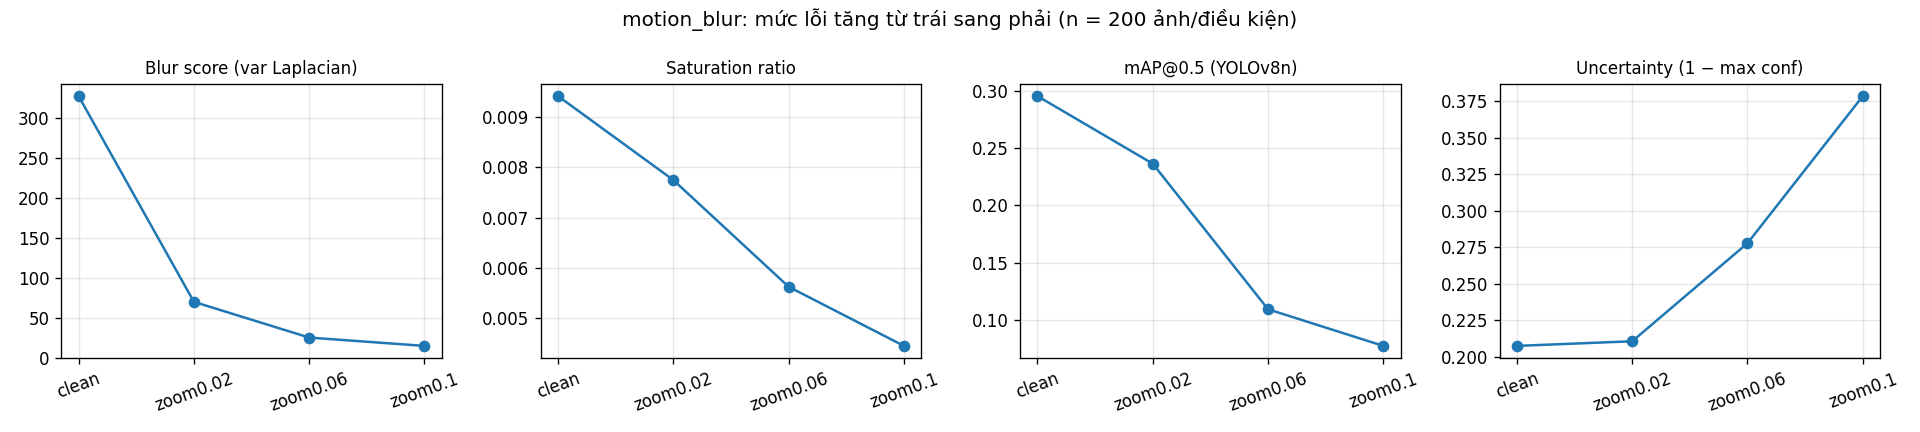

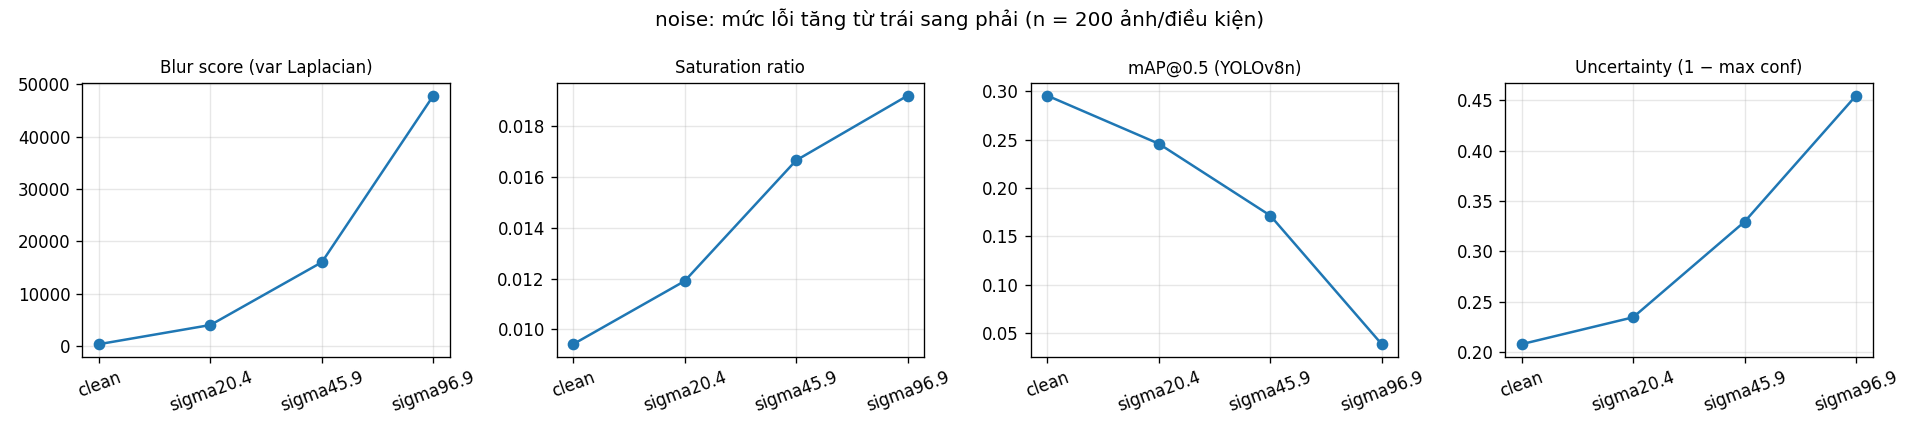

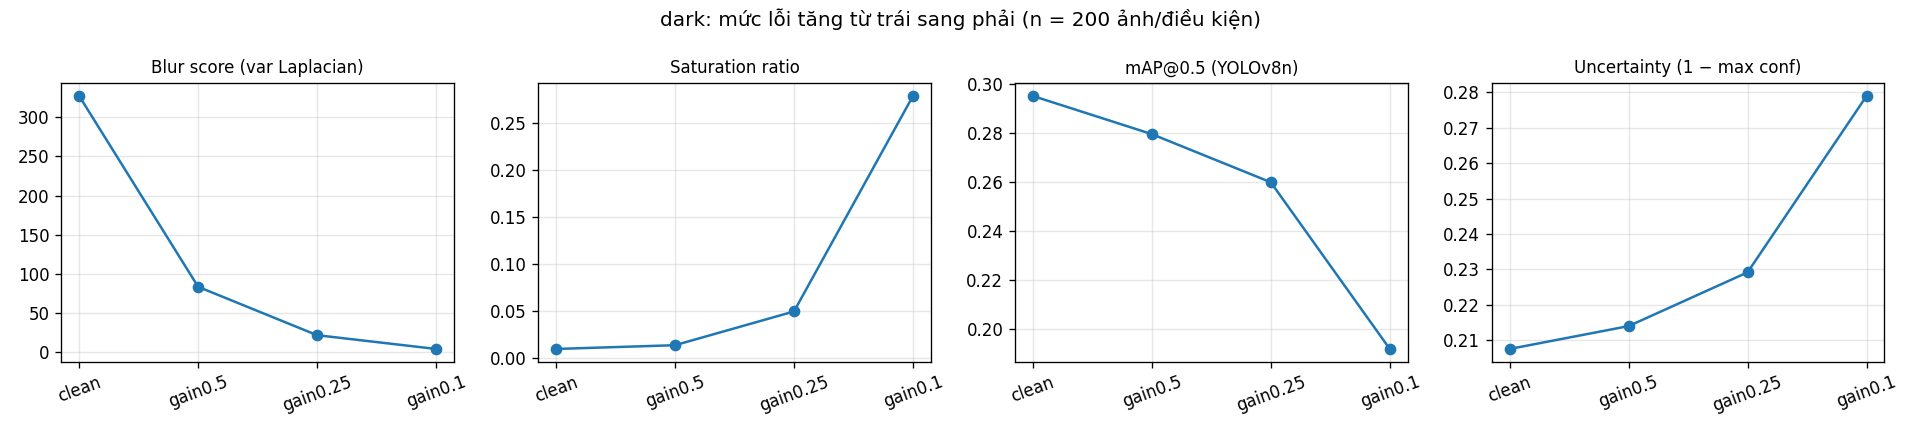

In [7]:
for fam in bm.DEFAULT_FAMILIES:
    display(Image(str(result["out_dir"] / f"plot_{fam}.png")))

**Ảnh trước/sau** — cùng một ảnh qua mọi điều kiện:

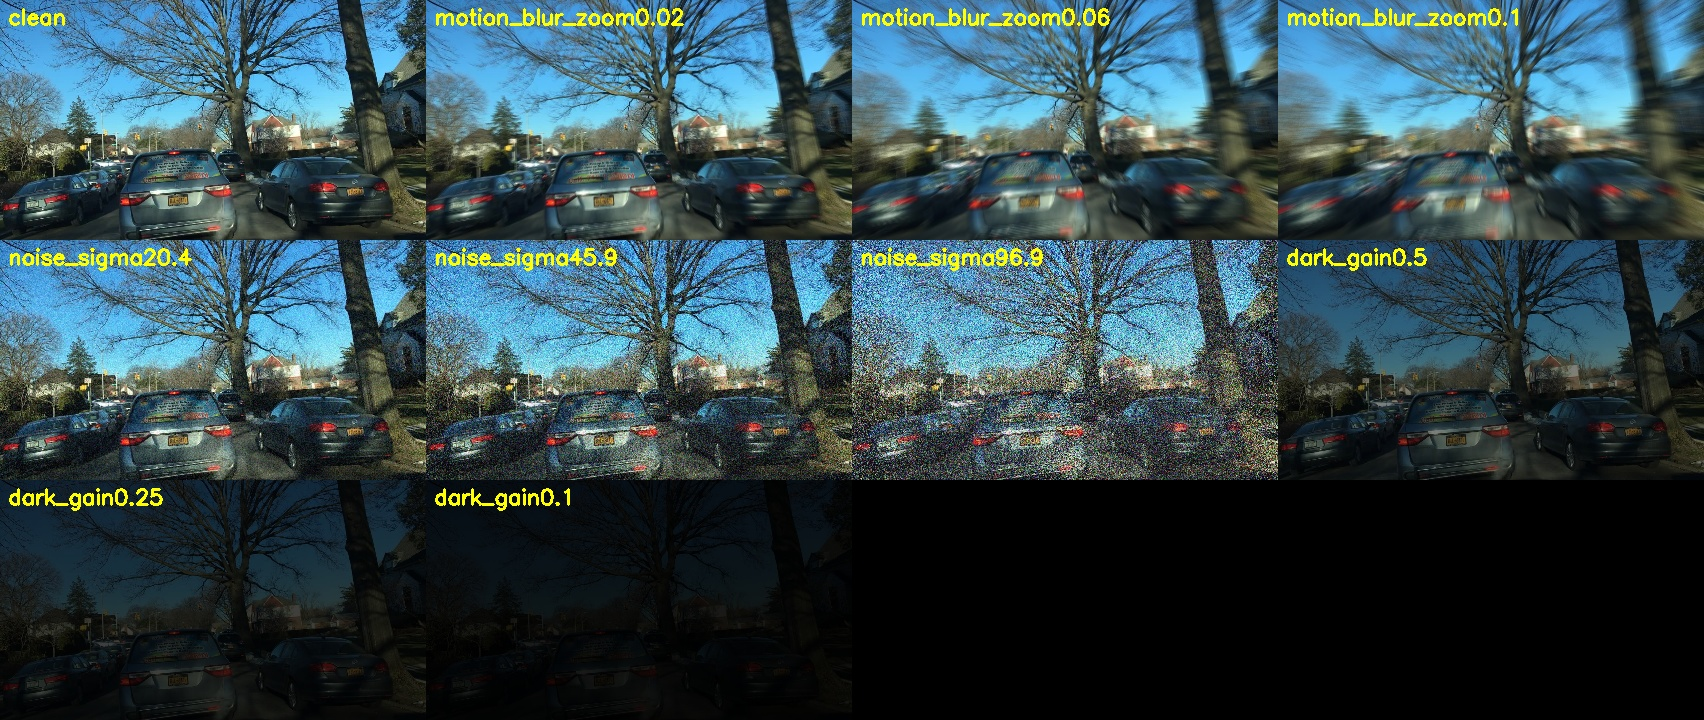

In [8]:
display(Image(str(result["out_dir"] / "examples.jpg")))

## 5. Chỉ số sức khỏe nào đi cùng chiều với mAP?

Tương quan hạng Spearman giữa từng chỉ số sức khỏe và mAP50, tính **trên 10 điều kiện mô phỏng** (cùng 200 ảnh).
Dấu đúng mong đợi: `blur_score` và `entropy_bits` dương (ảnh nét/giàu thông tin → mAP cao), `saturation_ratio` âm.

In [9]:
sim = summary[summary.family != "night_real"]
corr = {m: sim[m].corr(sim.mAP50, method="spearman") for m in ["blur_score", "saturation_ratio", "entropy_bits", "noise_est", "uncertainty"]}
pd.Series(corr, name="Spearman ρ với mAP50").to_frame()

,Spearman ρ với mAP50
blur_score,-0.018
saturation_ratio,0.127
entropy_bits,-0.285
noise_est,-0.127
uncertainty,-0.891


## 6. Uncertainty của detector có ưu tiên ảnh hỏng không?

Trộn baseline với 3 mức lỗi của một họ (4 × 200 ảnh), xếp theo `uncertainty` như khi chọn ảnh để gán nhãn,
lấy top-200. Nếu uncertainty không liên quan tới lỗi camera, mỗi mức chiếm khoảng 25 %.

In [10]:
result["topk"].pivot(index="condition", columns="family", values="share_of_topk").fillna("")

family,dark,motion_blur,noise
condition,,,
clean,0.215,0.135,0.095
dark_gain0.1,0.35,,
dark_gain0.25,0.24,,
dark_gain0.5,0.195,,
motion_blur_zoom0.02,,0.145,
motion_blur_zoom0.06,,0.275,
motion_blur_zoom0.1,,0.445,
noise_sigma20.4,,,0.125
noise_sigma45.9,,,0.245


## 7. Lỗi thật: ảnh đêm

Ảnh đêm là **ảnh khác** với baseline, nên chênh lệch gồm cả khác biệt cảnh, không chỉ do sensor. Dùng để xem các chỉ số
sức khỏe của ảnh đêm thật rơi vào vùng nào so với lỗi mô phỏng.

In [11]:
summary.set_index("condition").loc[["clean", "dark_gain0.25", "dark_gain0.1", "noise_sigma45.9", "night_real"],
                                  cols[2:]]

,blur_score,saturation_ratio,entropy_bits,noise_est,mean_max_conf,uncertainty,mAP50,mAP50_95,RCE
condition,,,,,,,,,
clean,327.092,0.009,7.487,0.746,0.792,0.208,0.295,0.173,0.000
dark_gain0.25,21.905,0.049,5.511,0.263,0.770,0.229,0.260,0.150,0.120
dark_gain0.1,4.362,0.279,4.219,0.154,0.711,0.279,0.192,0.105,0.351
noise_sigma45.9,15983.921,0.017,7.802,27.916,0.667,0.329,0.171,0.096,0.419
night_real,59.662,0.166,5.809,0.210,0.643,0.357,0.146,0.085,0.504


## 8. Thử nhanh cải tiến: cổng sức khỏe camera có thêm ước lượng nhiễu

Failure case ở mục 4–5: nhiễu làm `blur_score` và `entropy_bits` **tăng** — hai chỉ số báo ảnh "tốt hơn" đúng lúc mAP
sập. Nhóm thêm `noise_est` (Immerkær 1996, *Fast noise variance estimation*: lọc mặt nạ Laplacian bậc hai, giữ phần
nhiễu) và so hai cổng gắn cờ "camera không đáng tin" trên từng ảnh:

- **Cổng A (chỉ số cũ):** `blur_score` thấp hơn phân vị 5 % của ảnh sạch **hoặc** `saturation_ratio` cao hơn phân vị 95 %.
- **Cổng B (cải tiến):** cổng A **hoặc** `noise_est` cao hơn phân vị 95 % của ảnh sạch.

Ngưỡng lấy từ chính 200 ảnh sạch (in-sample), nên tỉ lệ báo nhầm trên ảnh sạch khoảng 5–10 % là do cách đặt ngưỡng.

In [12]:
per_image = result["per_image"]
clean = per_image[per_image.condition == "clean"]
thr = {"blur": clean.blur_score.quantile(0.05), "sat": clean.saturation_ratio.quantile(0.95),
       "noise": clean.noise_est.quantile(0.95)}
print({k: round(v, 4) for k, v in thr.items()})
gate_a = (per_image.blur_score < thr["blur"]) | (per_image.saturation_ratio > thr["sat"])
gate_b = gate_a | (per_image.noise_est > thr["noise"])
gates = (per_image.assign(gate_A=gate_a, gate_B=gate_b).groupby("condition", sort=False)[["gate_A", "gate_B"]].mean()
         .join(summary.set_index("condition")[["mAP50", "RCE"]]))
gates.rename(columns={"gate_A": "tỉ lệ gắn cờ — cổng A", "gate_B": "tỉ lệ gắn cờ — cổng B"})

{'blur': 95.2042, 'sat': 0.039, 'noise': 1.6313}


,tỉ lệ gắn cờ — cổng A,tỉ lệ gắn cờ — cổng B,mAP50,RCE
condition,,,,
clean,0.095,0.145,0.295,0.000
motion_blur_zoom0.02,0.725,0.725,0.236,0.199
motion_blur_zoom0.06,0.995,0.995,0.110,0.629
motion_blur_zoom0.1,1.000,1.000,0.078,0.737
noise_sigma20.4,0.025,1.000,0.246,0.168
noise_sigma45.9,0.035,1.000,0.171,0.419
noise_sigma96.9,0.015,1.000,0.039,0.869
dark_gain0.5,0.645,0.645,0.280,0.053
dark_gain0.25,1.000,1.000,0.260,0.120


**Chi phí của cổng:** thời gian tính bốn chỉ số sức khỏe trên một frame 1280×720, CPU, 1 luồng OpenCV (đo nhanh, 50 ảnh).

In [13]:
import time, cv2
cv2.setNumThreads(1)
frames = [cv2.imread(str(p)) for p in sorted((bm.ROOT / "work" / "main_n200_s0" / "clean" / "images").glob("*.jpg"))[:50]]
for f in frames[:3]:
    bm.health_metrics(f)  # khởi động
t = time.perf_counter()
for f in frames:
    bm.health_metrics(f)
print(f"health_metrics: {(time.perf_counter() - t) / len(frames) * 1000:.1f} ms/frame")

health_metrics: 15.7 ms/frame
